# AutoEncoders on Fashion MNIST

In [1]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as Transforms
# from torchsummary import summary

from matplotlib import pyplot as plt

## Parametros de Treino

In [ ]:
IMAGE_SIZE = 32
CHANNELS = 1
BATCH_SIZE = 128
EMBEDDING_DIM = 2
EPOCHS = 10
LEARNING_RATE = 1e-3

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [13]:
def get_dataloaders():
    transform = Transforms.Compose([
                    Transforms.ToTensor(),
                    Transforms.Pad(2)])

    # carrega dataset MNIST
    train_ds = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                          download=True, transform=transform)
    test_ds = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                         download=True, transform=transform)
    train_loader = DataLoader(dataset=train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=4)
    test_loader = DataLoader(dataset=test_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=4)
    return train_loader, test_loader
    

In [14]:
train_loader, test_loader = get_dataloaders()
print(next(iter(train_loader))[0].shape)

torch.Size([128, 1, 32, 32])


## Criando o Auto Encoder

In [5]:
# Encoder
class Encoder(nn.Module):

    def __init__(self, latents):
        super().__init__()
        self.latents = latents
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(in_features=2048, out_features=self.latents)
        )

    def forward(self, x):
        return self.model(x)

# Decoder
class Decoder(nn.Module):
    
    def __init__(self, latents):
        super().__init__()
        self.latents = latents
        self.fc = nn.Linear(self.latents, 2048)

        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=128, 
                               kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=128, out_channels=64, 
                               kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=64, out_channels=32, 
                   kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.reshape(x.shape[0], 128, 4, 4)
        x = self.model(x)
        return x



In [6]:
# AutoEncoder
class AE(nn.Module):
    def __init__(self, latents, device):
        super().__init__()
        self.encoder = Encoder(latents)
        self.decoder = Decoder(latents)
        self.device = device
        self.to(self.device)

    def forward(self, x):
        z = self.encoder(x)
        recon_x = self.decoder(z)      
        return recon_x

    def save_model(self, model_path='autoencoder.pth'):
        torch.save(self.state_dict(), model_path)

    def load_model(self, model_path='autoencoder.pth'):
        try:
            checkpoint = torch.load(model_path, map_location=self.device)
            self.load_state_dict(checkpoint)
            print(f"Pesos carregados com sucesso de: {model_path}")
        except Exception as e:
            print(f"Erro ao carregar pesos: {e}")

    def generate(self, z):
        return F.sigmoid(self.decoder(z))

ae = AE(EMBEDDING_DIM, device)

print(ae)

AE(
  (encoder): Encoder(
    (model): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
      (7): Linear(in_features=2048, out_features=2, bias=True)
    )
  )
  (decoder): Decoder(
    (fc): Linear(in_features=2, out_features=2048, bias=True)
    (model): Sequential(
      (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1

## Definir modelo e parametros de treinamento

In [15]:
ae = AE(EMBEDDING_DIM, device)

# if torch.__version__.split('.')[0] == '2':
#     torch.set_float32_matmul_precision('high')
#     ae = torch.compile(ae) # PyTorch 2.0 feature
#     print('model compiled')

loss_fn = nn.BCEWithLogitsLoss(reduction='mean')
optim = torch.optim.Adam(ae.parameters(), lr=LEARNING_RATE)

## Dataloaders

In [7]:
train_loader, test_loader = get_dataloaders()

## Funçoes de treino e validacao

In [16]:
# define treino de uma epoca 
def train(model, dataloader, optimizer, loss_fn):

    model.train()
    train_loss = 0

    for i, (train_x, train_y) in enumerate(dataloader):
        optimizer.zero_grad()
        train_x = train_x.to(device)
        recon_x = model(train_x)
        loss = loss_fn(recon_x, train_x)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    return train_loss / len(dataloader)

# funcao de validacao
def validate(model, dataloader, loss_fn):
    model.eval()
    test_loss = 0
    for i, (test_x, test_y) in enumerate(dataloader):
        test_x = test_x.to(device)
        with torch.no_grad():
            recon_x = model(test_x)
            loss = loss_fn(recon_x, test_x)

        test_loss += loss
    return test_loss / len(dataloader)

## Treino e avaliacao

In [17]:
for i in range(EPOCHS):
    train_loss = train(ae, train_loader, optim, loss_fn)
    test_loss = validate(ae, test_loader, loss_fn)

    print(f'Época {i + 1}')
    print(f'\tTreino - loss: {train_loss:.4f}')
    print(f'\tValid. - loss: {test_loss:.4f}')

Época 1
	Treino - loss: 0.2707
	Valid. - loss: 0.2278
Época 2
	Treino - loss: 0.2220
	Valid. - loss: 0.2202
Época 3
	Treino - loss: 0.2173
	Valid. - loss: 0.2176
Época 4
	Treino - loss: 0.2152
	Valid. - loss: 0.2160
Época 5
	Treino - loss: 0.2140
	Valid. - loss: 0.2151
Época 6
	Treino - loss: 0.2132
	Valid. - loss: 0.2146
Época 7
	Treino - loss: 0.2126
	Valid. - loss: 0.2139
Época 8
	Treino - loss: 0.2121
	Valid. - loss: 0.2136
Época 9
	Treino - loss: 0.2117
	Valid. - loss: 0.2135
Época 10
	Treino - loss: 0.2113
	Valid. - loss: 0.2128


## Usando o `Encoder`

In [ ]:
# caso queira salvar o modelo treinado, descomente a linha abaixo
# ae.save_model('autoencoder.pth') # voce pode escolher o nome do arquivo, mas mantenha a extensão .pth


In [ ]:
# caso queira carregar um modelo previamente treinado, descomente a linha abaixo
# Para usar 'autoencoder.pth', use EMBEDDING_DIM = 2
# Para usar 'autoencoder_dim10.pth', use EMBEDDING_DIM = 10
# ae.load_model('autoencoder.pth')


Pesos carregados com sucesso de: autoencoder.pth


In [25]:
num_samples = 5000
num_iters = np.ceil(num_samples / BATCH_SIZE).astype(int)

for i, (test_x, test_y) in enumerate(test_loader):
    test_x = test_x.to(device)
    with torch.no_grad():
        embeddings = ae.encoder(test_x)
    if i == 0:
        output_embs = embeddings
        output_labels = test_y
    else:
        output_embs = torch.concatenate([output_embs, embeddings])
        output_labels = torch.concatenate([output_labels, test_y])
    if i == num_iters - 1: break

output_embs = output_embs.detach().cpu().numpy()
output_labels = output_labels.detach().cpu().numpy()

# plot para embedding_dim = 2
if EMBEDDING_DIM == 2:
    plt.figure(figsize=(8, 8))
    plt.scatter(output_embs[:, 0], 
                output_embs[:, 1], 
                c=output_labels, 
                alpha=0.8,
                s=3)
    plt.show()

## Geracao usando o `Decoder`

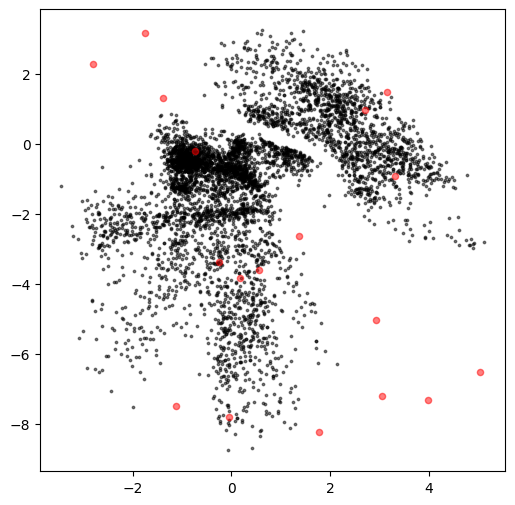

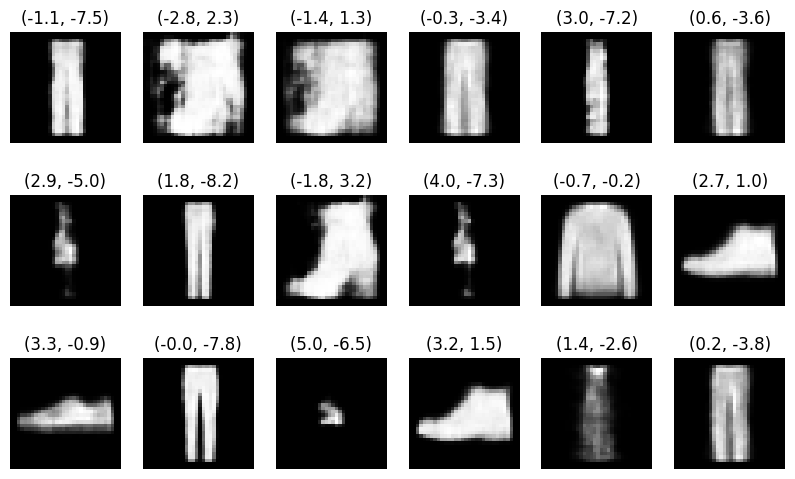

In [ ]:
if EMBEDDING_DIM == 2:
    # amostrando do "Espaço Amostral"
    x_min, x_max = output_embs[:, 0].min(), output_embs[:, 0].max()
    y_min, y_max = output_embs[:, 1].min(), output_embs[:, 1].max()

    xs = np.random.uniform(x_min, x_max, size=(18, 1))
    ys = np.random.uniform(y_min, y_max, size=(18, 1))
    samples = np.hstack([xs, ys])

    samples_torch = torch.tensor(samples, device=device, dtype=torch.float32)
    # print(samples.shape)
    with torch.no_grad():
        output_imgs = ae.generate(samples_torch).detach().cpu().numpy()
    output_imgs = output_imgs.transpose((0, 2, 3, 1))

    plt.figure(figsize=(6, 6))
    plt.scatter(output_embs[:, 0], 
                output_embs[:, 1], 
                c='black', 
                alpha=0.5,
                s=3)
    plt.scatter(samples[:, 0], 
                samples[:, 1], 
                c='red', 
                alpha=0.5,
                s=20)
    plt.show()

    # Gerando novas imagens a partir dos embeddings amostrados
    fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(10, 6))
    for i in range(output_imgs.shape[0]):
        curr_row = i // 6
        curr_col = i % 6
        ax = axes[curr_row, curr_col]
        
        ax.set_title(f'({samples[i][0]:.1f}, {samples[i][1]:.1f})')
        ax.axis('off')
        ax.imshow(output_imgs[i], cmap='gray')

    plt.show()
    

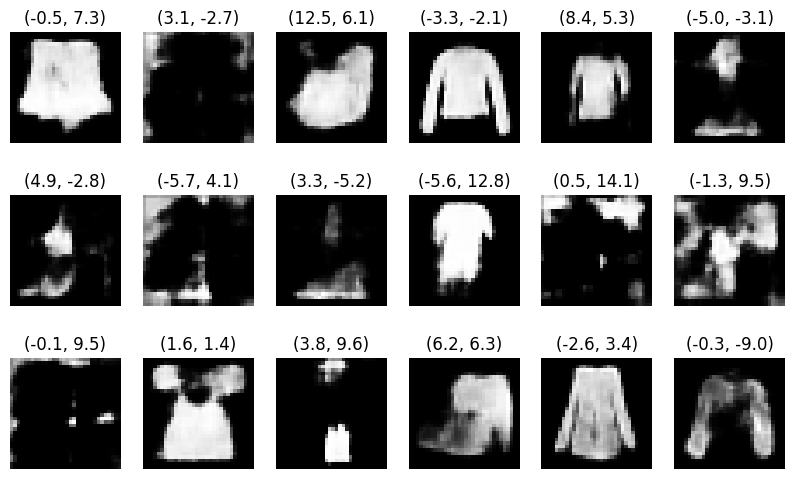

In [33]:
# usando o DECODER com EMBEDDING_DIM = 10
if EMBEDDING_DIM == 10:
    samples_10 = np.zeros((18, EMBEDDING_DIM))
    # agora, em vez de amostrar 2 dimensoes, amostraremos 10
    for i in range(EMBEDDING_DIM):
        v_min = output_embs[:, i].min()
        v_max = output_embs[:, i].max()
        samples_10[:, i] = np.random.uniform(v_min, v_max, size=(18,))
        
    samples_torch = torch.tensor(samples_10, device=device, dtype=torch.float32)
    with torch.no_grad():
        output_imgs = ae.generate(samples_torch).detach().cpu().numpy()
    output_imgs = output_imgs.transpose((0, 2, 3, 1))

    fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(10, 6))
    for i in range(output_imgs.shape[0]):
        curr_row = i // 6
        curr_col = i % 6
        ax = axes[curr_row, curr_col]
        
        ax.set_title(f'({samples_10[i][0]:.1f}, {samples_10[i][1]:.1f})')
        ax.axis('off')
        ax.imshow(output_imgs[i], cmap='gray')

    plt.show()